In [1]:
import sys
sys.path.append('../')
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pickle
import matplotlib
import matplotlib.pyplot as plt
# import seaborn as sns
from itertools import permutations
import random
import time
import os

from utils.metrics import RMSE
import utils.metrics as metrics
from simulators.ricker import ricker

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import warnings
warnings.filterwarnings('ignore')

c:\Users\azhao\.conda\envs\efficient-sbi\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\azhao\.conda\envs\efficient-sbi\lib\site-packages\arviz\data\base.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# you can pre-generate the data using generate_data.py
x = torch.tensor(np.load("../data/ricker_x_4000.npy")).reshape(4000, 100, 100).to(device)

theta = np.load("../data/ricker_theta_4000.npy")

dataloader = DataLoader(x[:1000], batch_size=200, shuffle=True)

In [3]:
def regression_ABC(s_obs, param, sumStats, p):
    def mad(data):
        return np.mean(np.abs(data - np.mean(data, axis=0)), axis=0)

    if param.shape[0] < param.shape[1]:
        param = np.transpose(param)

    if sumStats.shape[0] < sumStats.shape[1]:
        sumStats = np.transpose(sumStats)
    
    M = len(param)
    M_epsilon = int(M*p)
    sumStats = sumStats
    s_obs = s_obs

    norm_factor = mad(sumStats)

    norm_sumStats = sumStats / norm_factor
    norm_s_obs = s_obs / norm_factor

    distance = np.linalg.norm(norm_sumStats - norm_s_obs, axis = 1)
    max_accepted_distance = np.sort(distance)[M_epsilon - 1]

    posterior_samples = param[distance <= max_accepted_distance, :]
    norm_sumStats_star = norm_sumStats[distance <= max_accepted_distance, :]

    weights = 1 - (distance[distance <= max_accepted_distance] / max_accepted_distance)**2
    W = np.diag(weights)

    s_obs_norm = np.tile(norm_s_obs, (M_epsilon,1))
    X = np.column_stack((np.ones(shape = (M_epsilon,1)), norm_sumStats_star - s_obs_norm))

    A = np.matmul(X.T, W)

    solution = np.linalg.solve(np.matmul(A, X), np.matmul(A, posterior_samples))

    beta = solution[1:,:]

    posterior_samples_adjusted = posterior_samples - np.matmul((norm_sumStats_star - s_obs_norm), beta)

    return posterior_samples_adjusted
    

In [4]:
class RickerSummary(nn.Module):
    def __init__(self, input_size, hidden_dim):
        super(RickerSummary, self).__init__()

        self.hidden_dim = hidden_dim
        self.input_size = input_size
        
        self.encoder = nn.Sequential(nn.Conv1d(self.input_size, 4, 3, 4),
                                     nn.Conv1d(4, 4, 3, 4),
                                     nn.Conv1d(4, 4, 3, 4),
                                     )
        
        self.decoder = nn.Sequential(nn.ConvTranspose1d(4, 4, 3, 4),
                                     nn.ConvTranspose1d(4, 4, 3, 4),
                                     nn.ConvTranspose1d(4, self.input_size, 3, 4),
                                     nn.Upsample(100)
                                     )

    def forward(self, Y):
        embeddings = self.encoder(Y.reshape(-1, 1, 100))
        output = self.decoder(embeddings.reshape(-1, 4, 1)).reshape(-1, 100, 100)
        return output
    
    def forward_encoder(self, Y):
        embeddings = self.encoder(Y.reshape(-1, 1, 100)).reshape(-1, 100, 4)
        return embeddings

# ABC

In [5]:
def solve_normal():
    summary_net_normal = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_normal.parameters(), lr=0.01)

    # Train the model for some number of epochs
    num_epochs = 10
    time_list = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader:
            start_time = time.time()
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_normal(inputs)
            loss = criterion(outputs, inputs) / 10000

            loss.backward()
            optimizer.step()
            end_time = time.time()
            print(f"calculation time: {end_time - start_time}")
            time_list.append(end_time - start_time)
            if len(time_list) == 20:
                a = np.array(time_list)
                print(f"average: {np.mean(a)}({np.std(a)})")

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_normal

# ABC-RS

In [6]:
def solve_robust(beta, obs_cont):
    summary_net_robust = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_robust.parameters(), lr=0.01)

    index_list = [int(i) for i in range(len(x))]

    num_epochs = 10
    time_list = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader:
            start_time = time.time()
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_robust(inputs)

            random.shuffle(index_list)
            context_embeddings = torch.mean(summary_net_robust.forward_encoder(x[index_list[:200]]), dim=1)
            obs_embeddings = torch.mean(summary_net_robust.forward_encoder(obs_cont), dim=1)

            ae_loss = criterion(outputs, inputs) / 10000
            summary_loss = metrics.MMD_unweighted(context_embeddings, obs_embeddings, lengthscale=metrics.median_heuristic(context_embeddings))

            loss = ae_loss + beta*summary_loss

            loss.backward()
            optimizer.step()
            end_time = time.time()
            print(f"calculation time: {end_time - start_time}")
            time_list.append(end_time - start_time)
            if len(time_list) == 20:
                a = np.array(time_list)
                print(f"average: {np.mean(a)}({np.std(a)})")

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_robust

# Main training loop

In [7]:
degrees = [0, 0.1, 0.2]

for degree in degrees:
    obs_cont = torch.tensor(np.load(f"../data/ricker_obs_{int(degree * 10)}.npy")).to(device)

    n_sims = 100
    beta_list = [1, 2, 3, 4, 5, 10]
    for beta in beta_list:
        for i in range(n_sims):
            print(f"Simulation {i}")
            summary_net_normal = solve_normal()
            s_normal = torch.mean(summary_net_normal.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_normal = torch.mean(summary_net_normal.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_normal = regression_ABC(s_obs_normal, theta, s_normal, 0.05)

            summary_net_robust = solve_robust(beta, obs_cont)
            s_robust = torch.mean(summary_net_robust.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_robust = torch.mean(summary_net_robust.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_robust = regression_ABC(s_obs_robust, theta, s_robust, 0.05)

            root_name = f'../objects/ABC/ricker_final/degree={degree}/lambda={beta}/' + str(i)
            if not os.path.exists(root_name):
                os.makedirs(root_name)
            np.save(root_name + '/posterior_normal.npy', posterior_normal)
            np.save(root_name + '/posterior_robust.npy', posterior_robust)

Simulation 0
calculation time: 6.10058069229126
calculation time: 6.287426948547363
calculation time: 5.950273036956787
calculation time: 5.918917655944824
calculation time: 5.791626214981079
Epoch 1, Loss: 16.87104377746582
calculation time: 5.863256454467773
calculation time: 5.758044719696045
calculation time: 5.786830902099609
calculation time: 5.996833086013794
calculation time: 5.921988248825073
Epoch 2, Loss: 16.211670112609863
calculation time: 6.121115684509277
calculation time: 6.313421964645386
calculation time: 6.342672348022461
calculation time: 6.342935085296631
calculation time: 6.189378499984741
Epoch 3, Loss: 14.115513610839844
calculation time: 6.18970799446106
calculation time: 6.168643236160278
calculation time: 5.989664077758789
calculation time: 6.338566064834595
calculation time: 6.1633079051971436
average: 6.076759541034699(0.19310144081510994)
Epoch 4, Loss: 12.079788970947266
calculation time: 6.237807035446167
calculation time: 6.305030345916748
calculation t

KeyboardInterrupt: 

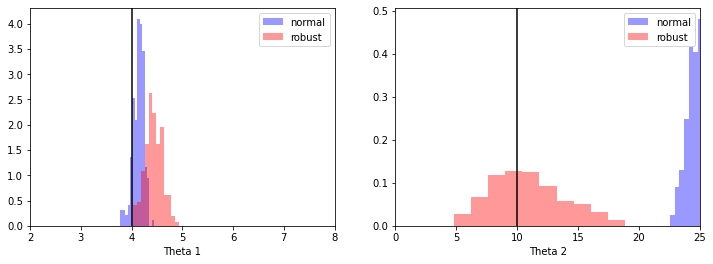

In [ ]:
import seaborn as sns

posterior_normal = np.load("../objects/ABC/ricker_final/degree=0.2/lambda=3/13/posterior_normal.npy")
posterior_robust = np.load("../objects/ABC/ricker_final/degree=0.2/lambda=3/7/posterior_robust.npy")

theta_gt = [4 ,10]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.axvline(x=theta_gt[0],ls="-",c="black")
sns.distplot(posterior_normal[:, 0], color='blue', kde=False, norm_hist=True, label="normal")
sns.distplot(posterior_robust[:, 0], color='red', kde=False, norm_hist=True, label="robust")
plt.legend()
plt.xlim(2, 8)
plt.xlabel("Theta 1")

plt.subplot(1, 2, 2)
plt.axvline(x=theta_gt[1],ls="-",c="black")
sns.distplot(posterior_normal[:, 1], color='blue', kde=False, norm_hist=True, label="normal")
sns.distplot(posterior_robust[:, 1], color='red', kde=False, norm_hist=True, label="robust")
plt.legend()
plt.xlim(0, 25)
plt.xlabel("Theta 2")

plt.show()

In [22]:
rmse_abc = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_normal), 2)
rmse_abc_rs = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_robust), 2)

print(f"RMSE for ABC: {rmse_abc}")
print(f"RMSE for ABC-RS: {rmse_abc_rs}")

RMSE for ABC: 10.51747176346229
RMSE for ABC-RS: 2.241420489998796


In [191]:
n_sims = 50
beta = 5
rmse_normal = np.zeros(n_sims)
rmse_robust = np.zeros(n_sims)
for i in range(n_sims):
    root_name = f'../objects/ABC/ricker/lambda={beta}/' + str(i)
    posterior_normal = torch.tensor(np.load(root_name + '/posterior_normal.npy'))
    posterior_robust = torch.tensor(np.load(root_name + '/posterior_robust.npy'))
    rmse_normal[i] = RMSE(torch.tensor([4, 10]), posterior_normal, 2)
    rmse_robust[i] = RMSE(torch.tensor([4, 10]), posterior_robust, 2)

print("RMSE mean for normal model: ", np.mean(rmse_normal))
print("RMSE mean for robust model: ", np.mean(rmse_robust))
print("RMSE std for normal model: ", np.std(rmse_normal))
print("RMSE std for robust model: ", np.std(rmse_robust))

RMSE mean for normal model:  7.067988529761993
RMSE mean for robust model:  3.891314436146103
RMSE std for normal model:  0.3422907645779606
RMSE std for robust model:  1.1737282202563097
